In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/telco_cleaned.csv')
print("Loaded:", df.shape)
df.head()

Loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.drop('customerID', axis=1, inplace=True)
print("Shape after drop:", df.shape)
print("Columns:", df.columns.tolist())

Shape after drop: (7043, 20)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# Reload fresh and redo from scratch
df = pd.read_csv('../data/processed/telco_cleaned.csv')
df.drop('customerID', axis=1, inplace=True)

# Check original values before mapping
print("Gender unique:", df['gender'].unique())
print("Churn unique:", df['Churn'].unique())
print("Partner unique:", df['Partner'].unique())
print("TechSupport unique:", df['TechSupport'].unique())

Gender unique: ['Female' 'Male']
Churn unique: ['No' 'Yes']
Partner unique: ['Yes' 'No']
TechSupport unique: ['No' 'Yes' 'No internet service']


In [4]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'No phone service': 0,
                           'No internet service': 0})

df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
df['Churn']  = df['Churn'].map({'Yes': 1, 'No': 0})

print(" Binary encoding done")
print(df[['gender', 'Churn', 'Partner', 'TechSupport']].head())
print("\nAny NaN?", df[['gender','Churn','Partner','TechSupport']].isnull().sum().sum())

 Binary encoding done
   gender  Churn  Partner  TechSupport
0       1      0        1            0
1       0      0        0            0
2       0      1        0            0
3       0      0        0            1
4       1      1        0            0

Any NaN? 0


In [5]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod']
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print(" One-hot encoding done")
print("New shape:", df.shape)
print([c for c in df.columns if any(x in c for x in cat_cols)])

 One-hot encoding done
New shape: (7043, 27)
['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [6]:
def tenure_group(t):
    if t <= 12:   return 0
    elif t <= 24: return 1
    elif t <= 48: return 2
    else:         return 3

df['tenure_group'] = df['tenure'].apply(tenure_group)
df['avg_monthly_spend_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
df['support_score'] = (df['OnlineSecurity'] + df['TechSupport'] +
                       df['OnlineBackup'] + df['DeviceProtection'])
df['streaming_count'] = df['StreamingTV'] + df['StreamingMovies']
df['is_high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)
df['engagement_score'] = (df['PhoneService'] + df['MultipleLines'] +
                          df['streaming_count'] + df['support_score'])

print(" Feature engineering done")
print("Final shape:", df.shape)
print(df[['tenure', 'tenure_group', 'support_score', 
          'streaming_count', 'is_high_value', 'engagement_score']].head())

 Feature engineering done
Final shape: (7043, 33)
   tenure  tenure_group  support_score  streaming_count  is_high_value  \
0       1             0              1                0              0   
1      34             2              2                0              0   
2       2             0              2                0              0   
3      45             2              3                0              0   
4       2             0              0                0              0   

   engagement_score  
0                 1  
1                 3  
2                 3  
3                 3  
4                 1  


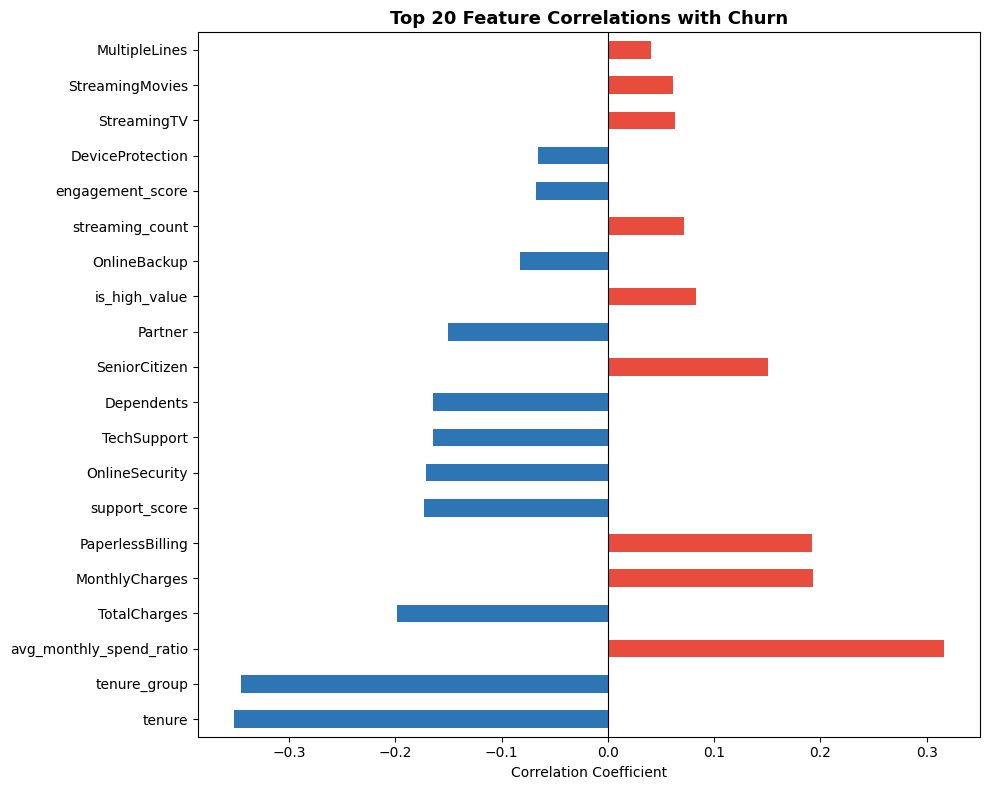

 Notebook 2 Complete!
  Features: 32 | Rows: 7,043
  Saved: data/processed/features.csv


In [7]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#E74C3C' if x > 0 else '#2E75B6' for x in correlations[:20]]
correlations[:20].plot(kind='barh', color=colors)
plt.title('Top 20 Feature Correlations with Churn', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/04_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

df.to_csv('../data/processed/features.csv', index=False)
print(" Notebook 2 Complete!")
print(f"  Features: {df.shape[1]-1} | Rows: {df.shape[0]:,}")
print(f"  Saved: data/processed/features.csv")